In [25]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [26]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [27]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [28]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [29]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [30]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9520859..1.9694828].


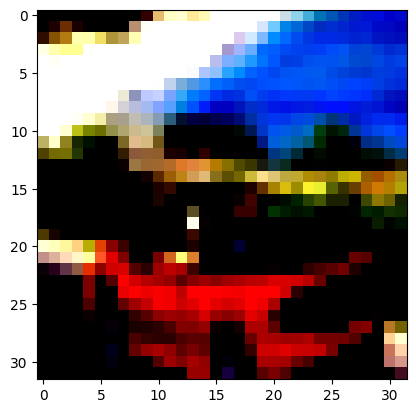

In [31]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [32]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [33]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [34]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [45]:
class Trainer:
    def __init__(self, config, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = BasicCNN().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )

        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            print(
                f"Epoch {epoch + 1}/{self.config['num_epochs']} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%"
            )

        test_loss, test_acc = self.test_step()
        print(f"Test loss={test_loss:.4f}, test acc={test_acc:.2f}%")

        return {
            'history': self.history,
            'test_loss': test_loss,
            'test_acc': test_acc
        }

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss /= len(self.train_loader)
        train_acc = correct / total_samples * 100
        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.val_loader):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        total_loss /= len(self.val_loader)
        val_acc = correct / total_samples * 100
        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.test_loader):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        total_loss /= len(self.test_loader)
        test_acc = correct / total_samples * 100
        return total_loss, test_acc

In [36]:
trainer = Trainer(config, transform=transform)

In [37]:
trainer.run()

100%|██████████| 79/79 [00:01<00:00, 45.70it/s]


Epoch 1 / 10 1.7429597625336326 1.5764004248607009 41.339999999999996


100%|██████████| 79/79 [00:01<00:00, 46.77it/s]


Epoch 2 / 10 1.4514038966486629 1.4527849683278724 46.949999999999996


100%|██████████| 79/79 [00:01<00:00, 45.98it/s]


...

Epoch 9 / 10 1.093378158994376 1.2048095253449451 56.26


100%|██████████| 79/79 [00:01<00:00, 47.06it/s]


Epoch 10 / 10 1.0802742640812175 1.204366607002065 56.74


100%|██████████| 79/79 [00:01<00:00, 46.97it/s]

Test loss 1.1983407177502596, test acc 57.38999999999999


# ResNet-18

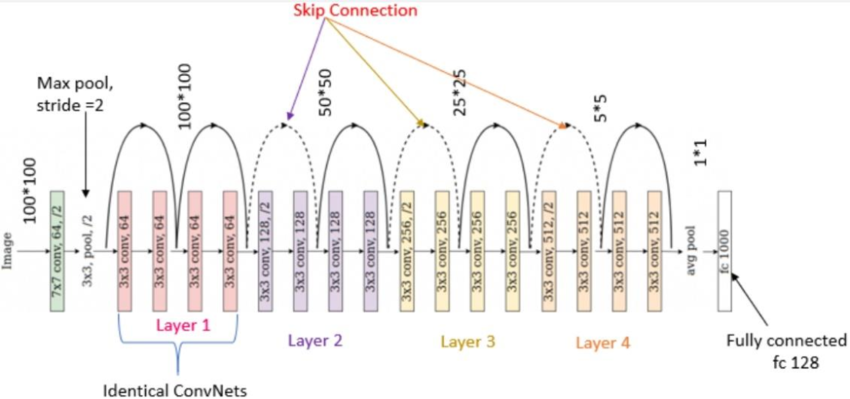

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F


class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(
            ResNetBlock(
                self.in_channels,
                out_channels,
                stride=stride,
                downsample=downsample
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [46]:
cnn_trainer = Trainer(config, transform=transform)
cnn_trainer.model = BasicCNN().to(cnn_trainer.device)
cnn_results = cnn_trainer.run()

100%|██████████| 79/79 [00:01<00:00, 48.03it/s]


Epoch 1/10 | train_loss=2.3041 train_acc=9.92% | val_loss=2.3026 val_acc=10.41%


100%|██████████| 79/79 [00:01<00:00, 44.77it/s]


Epoch 2/10 | train_loss=2.3041 train_acc=9.92% | val_loss=2.3026 val_acc=10.41%


100%|██████████| 79/79 [00:01<00:00, 45.98it/s]


...

Epoch 9/10 | train_loss=2.3040 train_acc=9.92% | val_loss=2.3026 val_acc=10.41%


100%|██████████| 79/79 [00:01<00:00, 51.16it/s]


Epoch 10/10 | train_loss=2.3041 train_acc=9.92% | val_loss=2.3026 val_acc=10.41%


100%|██████████| 79/79 [00:01<00:00, 46.23it/s]

Test loss=2.3038, test acc=10.01%


100%|██████████| 79/79 [00:01<00:00, 48.36it/s]


Epoch 1/10 | train_loss=2.6002 train_acc=10.22% | val_loss=2.5982 val_acc=10.66%


100%|██████████| 79/79 [00:01<00:00, 48.30it/s]


Epoch 2/10 | train_loss=2.5998 train_acc=10.36% | val_loss=2.6023 val_acc=10.54%


100%|██████████| 79/79 [00:01<00:00, 49.47it/s]


...

Epoch 9/10 | train_loss=2.6007 train_acc=10.30% | val_loss=2.5951 val_acc=10.34%


100%|██████████| 79/79 [00:01<00:00, 48.73it/s]


Epoch 10/10 | train_loss=2.6009 train_acc=10.29% | val_loss=2.5960 val_acc=10.24%


100%|██████████| 79/79 [00:01<00:00, 44.34it/s]


Test loss=2.5905, test acc=10.63%


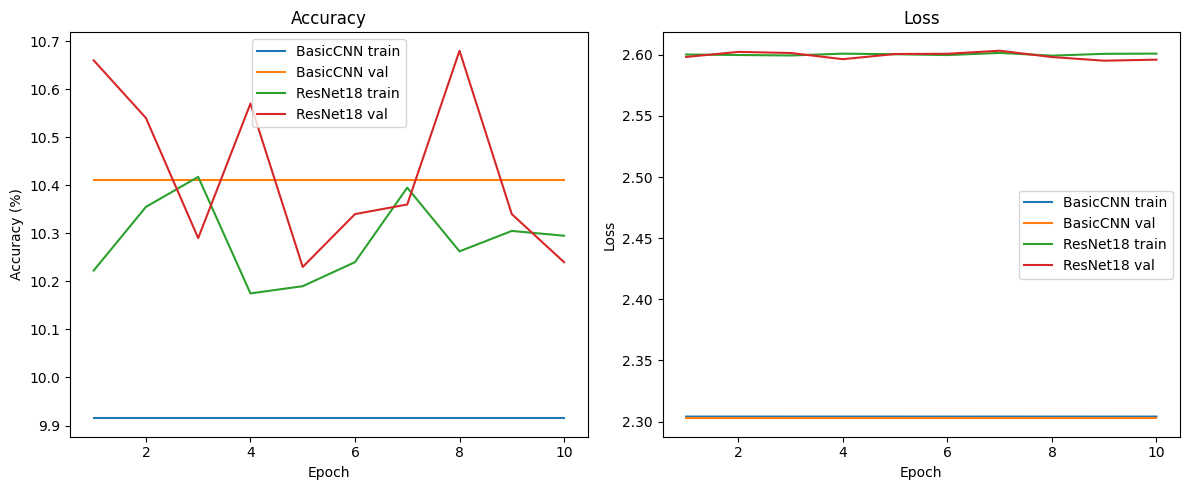

BasicCNN test acc: 10.01%
ResNet18 test acc: 10.63%


In [47]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

resnet_trainer = Trainer(config, transform=transform)
resnet_trainer.model = ResNet18(num_classes=10).to(resnet_trainer.device)
resnet_results = resnet_trainer.run()


epochs = range(1, config['num_epochs'] + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_results['history']['train_acc'], label='BasicCNN train')
plt.plot(epochs, cnn_results['history']['val_acc'], label='BasicCNN val')

plt.plot(epochs, resnet_results['history']['train_acc'], label='ResNet18 train')
plt.plot(epochs, resnet_results['history']['val_acc'], label='ResNet18 val')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_results['history']['train_loss'], label='BasicCNN train')
plt.plot(epochs, cnn_results['history']['val_loss'], label='BasicCNN val')

plt.plot(epochs, resnet_results['history']['train_loss'], label='ResNet18 train')
plt.plot(epochs, resnet_results['history']['val_loss'], label='ResNet18 val')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


print(f"BasicCNN test acc: {cnn_results['test_acc']:.2f}%")
print(f"ResNet18 test acc: {resnet_results['test_acc']:.2f}%")

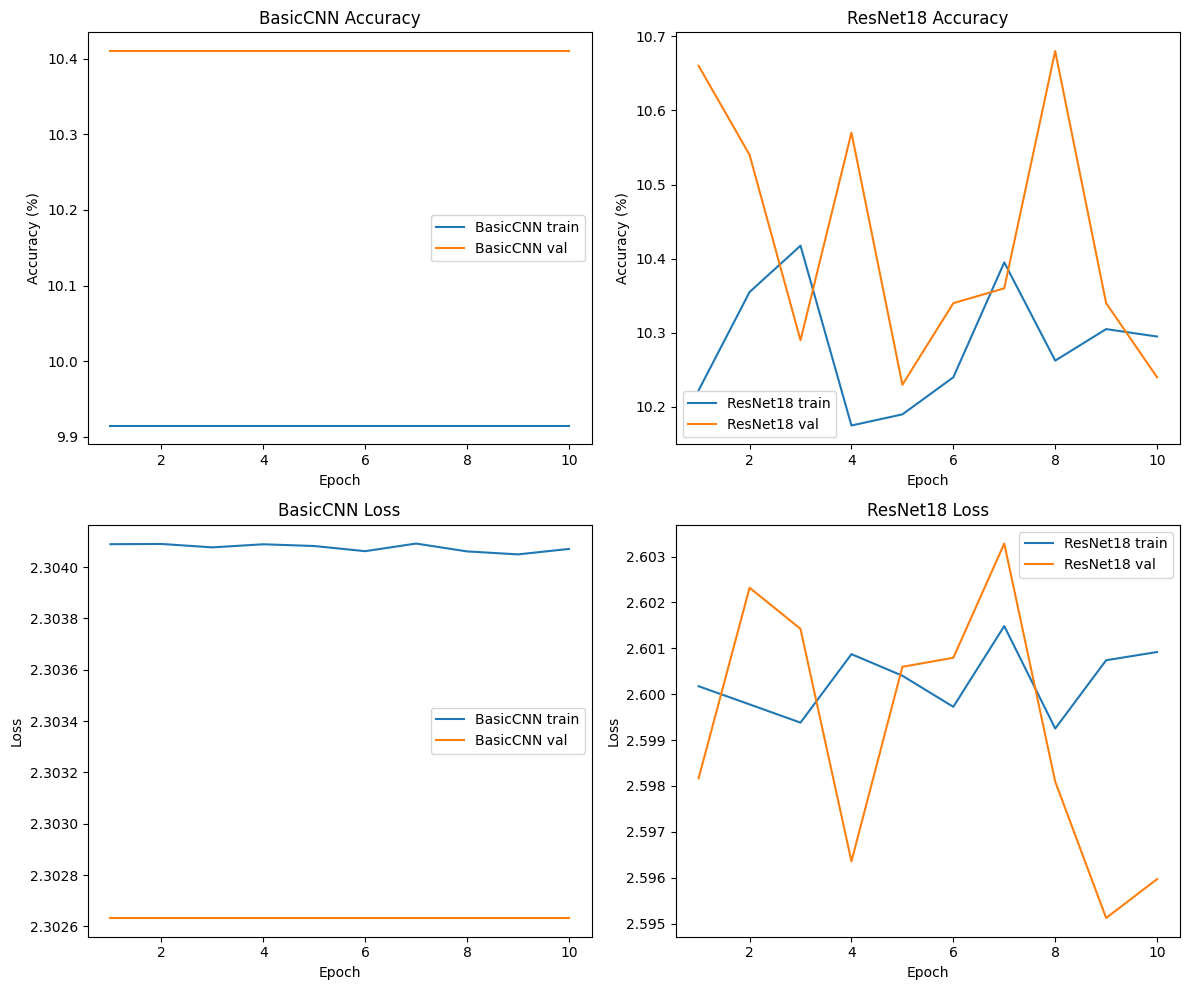

In [48]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs, cnn_results['history']['train_acc'], label='BasicCNN train')
plt.plot(epochs, cnn_results['history']['val_acc'], label='BasicCNN val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('BasicCNN Accuracy')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs, resnet_results['history']['train_acc'], label='ResNet18 train')
plt.plot(epochs, resnet_results['history']['val_acc'], label='ResNet18 val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('ResNet18 Accuracy')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs, cnn_results['history']['train_loss'], label='BasicCNN train')
plt.plot(epochs, cnn_results['history']['val_loss'], label='BasicCNN val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BasicCNN Loss')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs, resnet_results['history']['train_loss'], label='ResNet18 train')
plt.plot(epochs, resnet_results['history']['val_loss'], label='ResNet18 val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet18 Loss')
plt.legend()

plt.tight_layout()
plt.show()